In [35]:

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

In [36]:
def calc_gflops(N, time_ms):
    t_sec = time_ms / 1000.0
    return (2 * (N ** 3)) / t_sec / 1e9


def speedup(new, old):
    return new / old


def efficiency_percent(base, improved):
    return (improved / base - 1) * 100


def add_record(records, algorithm, N, time_ms, perf=None, S=None, M=None,
               correctness=None, transpose_included=None, note=None):
    if perf is None and time_ms is not None:
        perf = calc_gflops(N, time_ms)
    records.append({
        "algorithm": algorithm,
        "N": N,
        "S": S,
        "M": M,
        "time_ms": time_ms,
        "perf_gflops": perf,
        "correctness": correctness,
        "transpose_included": transpose_included,
        "note": note
    })

In [37]:
import re
import pandas as pd


def _to_number(x):
    if x is None:
        return None
    if "." in str(x):
        return float(x)
    return int(x)


def _clean_raw_text(raw_text: str) -> str:
    text = raw_text.replace("\r\n", "\n").replace("\r", "\n")

    # Убираем префиксы сообщений чата в начале строк
    text = re.sub(
        r"^\[\d{2}\.\d{2}\.\d{4}\s+\d{2}:\d{2}\]\s+.*?:\s*",
        "",
        text,
        flags=re.M
    )

    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


def parse_benchmark_text(raw_text: str):
    text = _clean_raw_text(raw_text)

    summary_records = []
    buffered_records = []
    blocked_records = []
    correctness_records = []

    current_N = None

    re_header_N = re.compile(r"^\s*N\s*=\s*(\d+)\s*$", re.I)

    re_buffered_detail = re.compile(
        r"Buffered:\s*M\s*=\s*(\d+),\s*N\s*=\s*(\d+),\s*t\s*=\s*([\d.]+)\s*ms,\s*P\s*=\s*([\d.]+)\s*GFLOP/s",
        re.I
    )
    re_blocked_detail = re.compile(
        r"Blocked:\s*S\s*=\s*(\d+),\s*M\s*=\s*(\d+),\s*N\s*=\s*(\d+),\s*t\s*=\s*([\d.]+)\s*ms,\s*P\s*=\s*([\d.]+)\s*GFLOP/s",
        re.I
    )

    re_summary_generic = re.compile(
        r"^(Classic|Transposed\s*\(\+prep\)|Transposed only|Buffered|Blocked)"
        r"\s+N\s*=\s*(\d+)\s+time\s*=\s*([\d.]+)\s*ms\s+perf\s*=\s*([\d.]+)\s*GFLOP/s\s*$",
        re.I
    )

    re_best_buffered = re.compile(r"^Buffered:\s*M\s*=\s*(\d+)\s*$", re.I)
    re_best_blocked = re.compile(r"^Blocked\s*:\s*S\s*=\s*(\d+),\s*M\s*=\s*(\d+)\s*$", re.I)

    re_correctness = re.compile(
        r"^(Classic vs Transposed|Classic vs Buffered|Classic vs Blocked)\s*:\s*(OK|FAIL)\s*$",
        re.I
    )

    best_params_by_n = {}

    lines = [line.strip() for line in text.split("\n")]

    for line in lines:
        if not line:
            continue

        m = re_header_N.match(line)
        if m:
            current_N = int(m.group(1))
            best_params_by_n.setdefault(current_N, {})
            continue

        m = re_buffered_detail.search(line)
        if m:
            M, N, t, p = m.groups()
            buffered_records.append({
                "algorithm": "Buffered",
                "N": int(N),
                "M": int(M),
                "time_ms": float(t),
                "perf_gflops": float(p),
            })
            continue

        m = re_blocked_detail.search(line)
        if m:
            S, M, N, t, p = m.groups()
            blocked_records.append({
                "algorithm": "Blocked",
                "N": int(N),
                "S": int(S),
                "M": int(M),
                "time_ms": float(t),
                "perf_gflops": float(p),
            })
            continue

        m = re_summary_generic.match(line)
        if m:
            algorithm, N, t, p = m.groups()
            N = int(N)

            algorithm = re.sub(r"\s+", " ", algorithm).strip()
            row = {
                "algorithm": algorithm,
                "N": N,
                "time_ms": float(t),
                "perf_gflops": float(p),
            }

            if algorithm == "Transposed (+prep)":
                row["transpose_included"] = True
            elif algorithm == "Transposed only":
                row["transpose_included"] = False

            summary_records.append(row)
            continue

        m = re_best_buffered.match(line)
        if m and current_N is not None:
            best_params_by_n.setdefault(current_N, {})
            best_params_by_n[current_N]["buffered_M"] = int(m.group(1))
            continue

        m = re_best_blocked.match(line)
        if m and current_N is not None:
            S, M = m.groups()
            best_params_by_n.setdefault(current_N, {})
            best_params_by_n[current_N]["blocked_S"] = int(S)
            best_params_by_n[current_N]["blocked_M"] = int(M)
            continue

        if m:
            compare_name, status = m.groups()
            correctness_records.append({
                "N": current_N,
                "comparison": compare_name,
                "status": status.upper(),
            })
            continue

    df_summary = pd.DataFrame(summary_records)
    df_buffered = pd.DataFrame(buffered_records)
    df_blocked = pd.DataFrame(blocked_records)
    df_correctness = pd.DataFrame(correctness_records)

    if not df_summary.empty:
        if "M" not in df_summary.columns:
            df_summary["M"] = pd.NA
        if "S" not in df_summary.columns:
            df_summary["S"] = pd.NA

        for n, params in best_params_by_n.items():
            mask_buf = (df_summary["N"] == n) & (df_summary["algorithm"] == "Buffered")
            if "buffered_M" in params:
                df_summary.loc[mask_buf, "M"] = params["buffered_M"]

            mask_blk = (df_summary["N"] == n) & (df_summary["algorithm"] == "Blocked")
            if "blocked_S" in params:
                df_summary.loc[mask_blk, "S"] = params["blocked_S"]
            if "blocked_M" in params:
                df_summary.loc[mask_blk, "M"] = params["blocked_M"]

        df_summary = df_summary.sort_values(["N", "algorithm"]).reset_index(drop=True)

    if not df_buffered.empty:
        df_buffered = df_buffered.sort_values(["N", "M"]).reset_index(drop=True)

    if not df_blocked.empty:
        df_blocked = df_blocked.sort_values(["N", "S", "M"]).reset_index(drop=True)

    if not df_correctness.empty:
        df_correctness = df_correctness.sort_values(["N", "comparison"]).reset_index(drop=True)

    if not df_buffered.empty:
        df_best_buffered = (
            df_buffered.sort_values(["N", "perf_gflops"], ascending=[True, False])
            .groupby("N", as_index=False)
            .first()[["N", "M", "time_ms", "perf_gflops"]]
            .rename(columns={
                "M": "best_M",
                "time_ms": "best_time_ms",
                "perf_gflops": "best_perf_gflops"
            })
        )
    else:
        df_best_buffered = pd.DataFrame()

    if not df_blocked.empty:
        df_best_blocked = (
            df_blocked.sort_values(["N", "perf_gflops"], ascending=[True, False])
            .groupby("N", as_index=False)
            .first()[["N", "S", "M", "time_ms", "perf_gflops"]]
            .rename(columns={
                "S": "best_S",
                "M": "best_M",
                "time_ms": "best_time_ms",
                "perf_gflops": "best_perf_gflops"
            })
        )
    else:
        df_best_blocked = pd.DataFrame()

    if not df_summary.empty:
        df_best_per_n = (
            df_summary.sort_values(["N", "perf_gflops"], ascending=[True, False])
            .groupby("N", as_index=False)
            .first()[["N", "algorithm", "time_ms", "perf_gflops", "S", "M"]]
            .rename(columns={
                "algorithm": "best_algorithm",
                "time_ms": "best_time_ms",
                "perf_gflops": "best_perf_gflops",
            })
        )
    else:
        df_best_per_n = pd.DataFrame()

    return {
        "summary_records": summary_records,
        "buffered_records": buffered_records,
        "blocked_records": blocked_records,
        "correctness_records": correctness_records,
        "df_summary": df_summary,
        "df_buffered": df_buffered,
        "df_blocked": df_blocked,
        "df_correctness": df_correctness,
        "df_best_buffered": df_best_buffered,
        "df_best_blocked": df_best_blocked,
        "df_best_per_n": df_best_per_n,
        "clean_text": text,
    }

In [38]:
with open("res.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

parsed = parse_benchmark_text(raw_text)

df_summary = parsed["df_summary"]
df_buffered = parsed["df_buffered"]
df_blocked = parsed["df_blocked"]
df_correctness = parsed["df_correctness"]
df_best_per_n = parsed["df_best_per_n"]

print(df_summary)
print(df_best_per_n)

             algorithm     N     time_ms  perf_gflops transpose_included     M     S
0              Blocked    16       0.002        4.551                NaN    16    16
1             Buffered    16       0.003        3.151                NaN     2  <NA>
2              Classic    16       0.001        9.102                NaN  <NA>  <NA>
3   Transposed (+prep)    16       0.001        9.102               True  <NA>  <NA>
4      Transposed only    16       0.001        9.102              False  <NA>  <NA>
5              Blocked    32       0.009        7.533                NaN     8    32
6             Buffered    32       0.019        3.468                NaN    16  <NA>
7              Classic    32       0.014        4.648                NaN  <NA>  <NA>
8   Transposed (+prep)    32       0.014        4.784               True  <NA>  <NA>
9      Transposed only    32       0.012        5.461              False  <NA>  <NA>
10             Blocked    64       0.071        7.384            

In [39]:
debug_release = pd.DataFrame([
    {"N": 8192, "config": "Debug", "algorithm": "Classic", "time_ms": 2474577.163, "perf_gflops": 0.444},
    {"N": 8192, "config": "Release", "algorithm": "Classic", "time_ms": 2163416.563, "perf_gflops": 0.508},
])

debug_release

,N,config,algorithm,time_ms,perf_gflops
0,8192,Debug,Classic,2474577.163,0.444
1,8192,Release,Classic,2163416.563,0.508


In [40]:
dbg = debug_release.loc[debug_release["config"] == "Debug"].iloc[0]
rel = debug_release.loc[debug_release["config"] == "Release"].iloc[0]

classic_speedup = speedup(dbg["time_ms"], rel["time_ms"])
perf_gain = speedup(rel["perf_gflops"], dbg["perf_gflops"])
time_reduction_percent = (1 - rel["time_ms"] / dbg["time_ms"]) * 100
perf_increase_percent = (rel["perf_gflops"] / dbg["perf_gflops"] - 1) * 100

print(f"N = 8192")
print(f"Debug time   = {dbg['time_ms']:.3f} ms")
print(f"Release time = {rel['time_ms']:.3f} ms")
print(f"Ускорение по времени = {classic_speedup:.3f}x")
print(f"Сокращение времени   = {time_reduction_percent:.2f}%")
print(f"Рост производительности = {perf_increase_percent:.2f}%")
print(f"Рост GFLOP/s = {perf_gain:.3f}x")

N = 8192
Debug time   = 2474577.163 ms
Release time = 2163416.563 ms
Ускорение по времени = 1.144x
Сокращение времени   = 12.57%
Рост производительности = 14.41%
Рост GFLOP/s = 1.144x


In [41]:
best_buffered = (
    df_buffered.sort_values(["N", "perf_gflops"], ascending=[True, False])
    .groupby("N", as_index=False)
    .first()[["N", "M", "time_ms", "perf_gflops"]]
    .rename(columns={
        "M": "best_M",
        "time_ms": "best_time_ms",
        "perf_gflops": "best_perf_gflops"
    })
)

best_buffered

,N,best_M,best_time_ms,best_perf_gflops
0,16,2,0.003,3.277
1,32,16,0.009,7.202
2,64,8,0.055,9.515
3,128,4,0.410,10.235
4,256,2,3.168,10.591
5,512,8,25.890,10.368
6,1024,8,203.206,10.568
7,2048,2,1864.631,9.214
8,4096,8,20900.434,6.576


In [42]:
best_buffered = (
    df_buffered.sort_values(["N", "perf_gflops"], ascending=[True, False])
    .groupby("N", as_index=False)
    .first()[["N", "M", "time_ms", "perf_gflops"]]
    .rename(columns={
        "M": "best_M",
        "time_ms": "best_time_ms",
        "perf_gflops": "best_perf_gflops"
    })
)

best_buffered

,N,best_M,best_time_ms,best_perf_gflops
0,16,2,0.003,3.277
1,32,16,0.009,7.202
2,64,8,0.055,9.515
3,128,4,0.410,10.235
4,256,2,3.168,10.591
5,512,8,25.890,10.368
6,1024,8,203.206,10.568
7,2048,2,1864.631,9.214
8,4096,8,20900.434,6.576


In [43]:
import pandas as pd

# Для каждого N выбираем строку с максимальной производительностью
blocked_best = (
    df_blocked
    .sort_values(["N", "perf_gflops"], ascending=[True, False])
    .groupby("N", as_index=False)
    .first()
)

# Переименовываем колонки под красивый вывод
blocked_best = blocked_best.rename(columns={
    "S": "S*",
    "M": "M*",
    "time_ms": "Время, мс",
    "perf_gflops": "Производительность, GFLOP/s"
})

# Оставляем нужные столбцы и сортируем
blocked_best = blocked_best[[
    "N", "S*", "M*", "Время, мс", "Производительность, GFLOP/s"
]].sort_values("N")

# (опционально) округление для красивого вывода
blocked_best["Время, мс"] = blocked_best["Время, мс"].round(3)
blocked_best["Производительность, GFLOP/s"] = blocked_best["Производительность, GFLOP/s"].round(3)

blocked_best

,N,S*,M*,"Время, мс","Производительность, GFLOP/s"
0,16,16,16,0.002,4.819
1,32,32,8,0.009,7.533
2,64,32,8,0.067,7.814
3,128,64,8,0.453,9.259
4,256,256,4,3.431,9.780
5,512,512,8,25.657,10.462
6,1024,1024,8,204.349,10.509
7,2048,1024,8,1602.278,10.722
8,4096,1024,8,13838.368,9.932


In [44]:
best_algorithms = df_summary.copy()
best_algorithms = best_algorithms.sort_values(["N", "algorithm"]).reset_index(drop=True)
best_algorithms

,algorithm,N,time_ms,perf_gflops,transpose_included,M,S
0,Blocked,16,0.002,4.551,NaN,16,16
1,Buffered,16,0.003,3.151,NaN,2,<NA>
2,Classic,16,0.001,9.102,NaN,<NA>,<NA>
3,Transposed (+prep),16,0.001,9.102,True,<NA>,<NA>
4,Transposed only,16,0.001,9.102,False,<NA>,<NA>
5,Blocked,32,0.009,7.533,NaN,8,32
6,Buffered,32,0.019,3.468,NaN,16,<NA>
7,Classic,32,0.014,4.648,NaN,<NA>,<NA>
8,Transposed (+prep),32,0.014,4.784,True,<NA>,<NA>
9,Transposed only,32,0.012,5.461,False,<NA>,<NA>


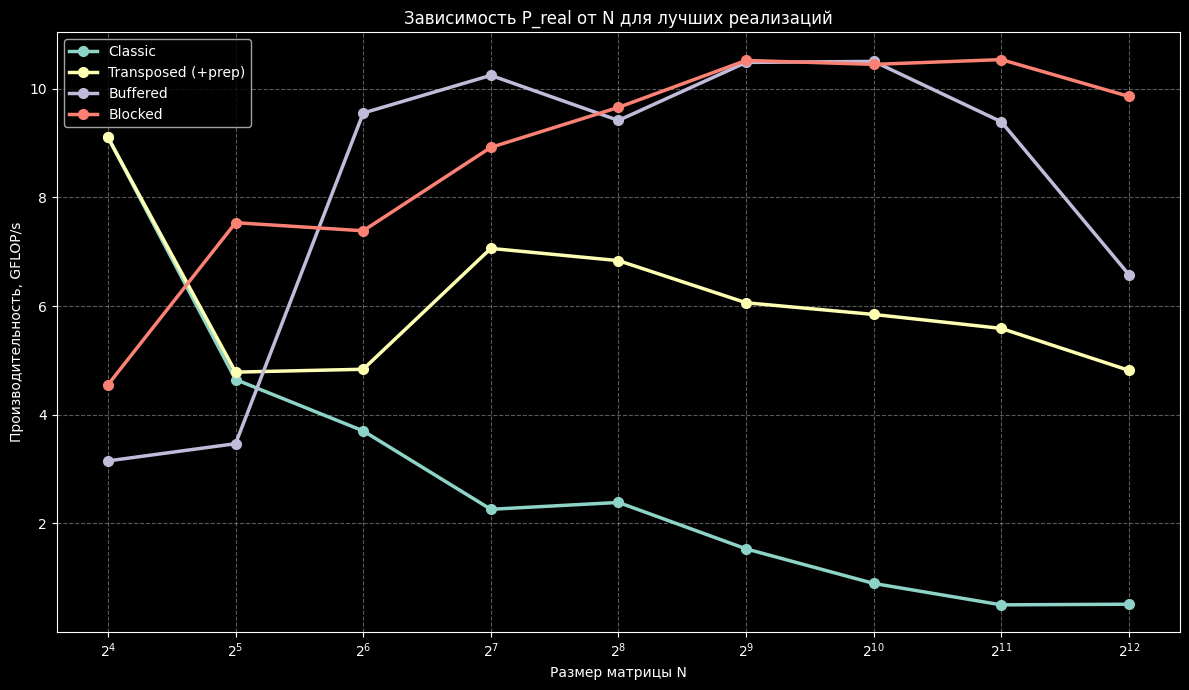

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

for alg in ["Classic", "Transposed (+prep)", "Buffered", "Blocked"]:
    part = df_summary[df_summary["algorithm"] == alg].sort_values("N")
    ax.plot(
        part["N"],
        part["perf_gflops"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=alg
    )

ax.set_xscale("log", base=2)
ax.set_xlabel("Размер матрицы N")
ax.set_ylabel("Производительность, GFLOP/s")
ax.set_title("Зависимость P_real от N для лучших реализаций")

ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.35)

plt.legend()
plt.tight_layout()
plt.show()

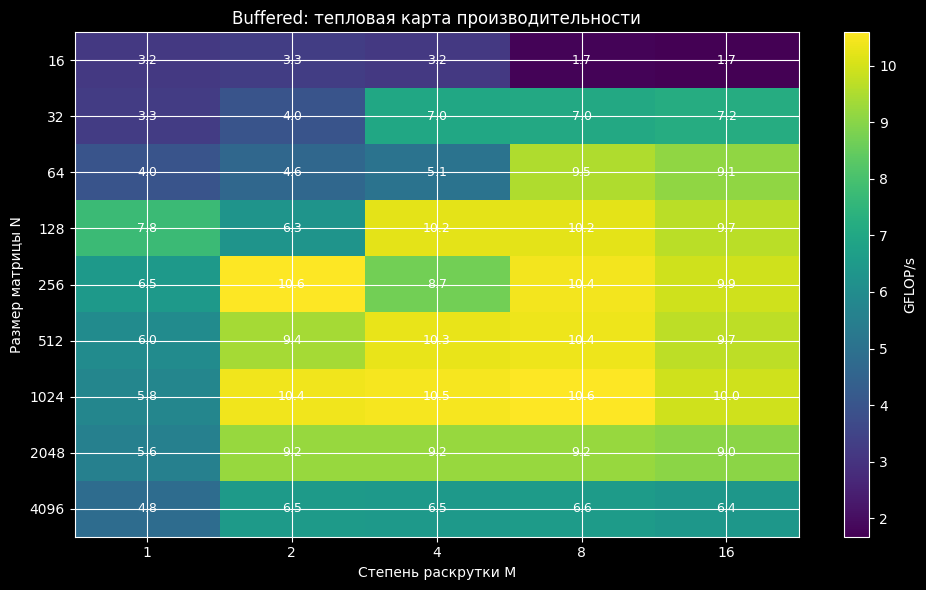

In [46]:
pivot = df_buffered.pivot(index="N", columns="M", values="perf_gflops")
pivot = pivot.sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(pivot.values, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("Степень раскрутки M")
ax.set_ylabel("Размер матрицы N")
ax.set_title("Buffered: тепловая карта производительности")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("GFLOP/s")

# Подписи значений в ячейках
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

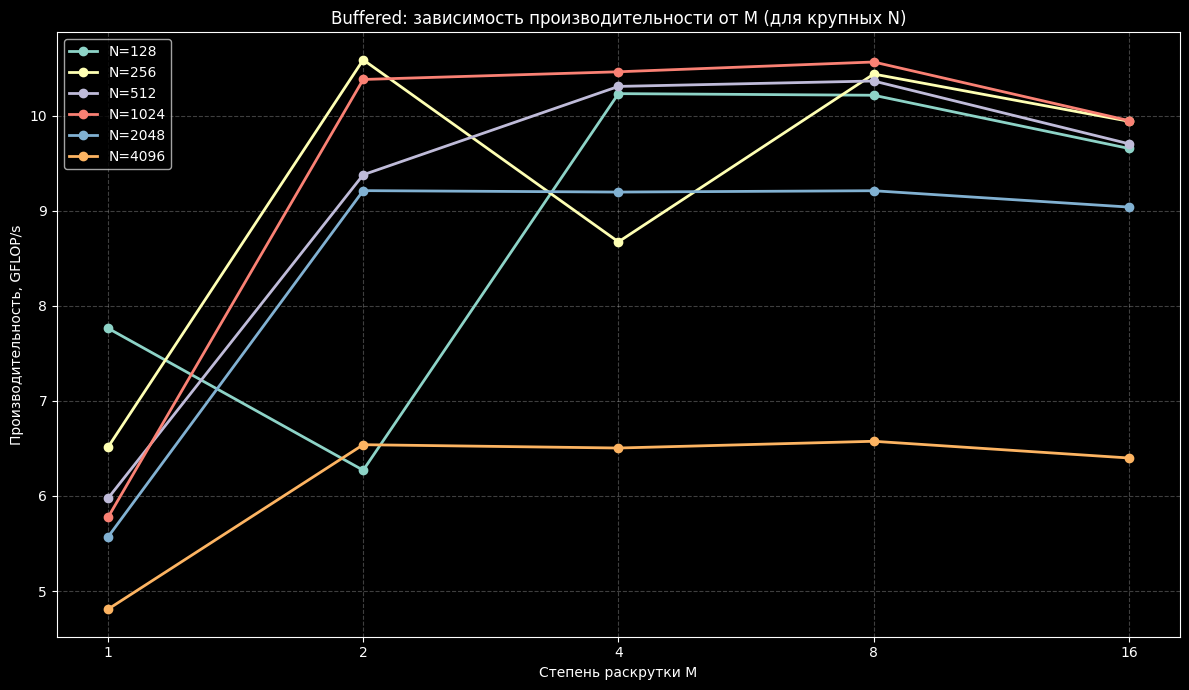

In [47]:
fig, ax = plt.subplots(figsize=(12, 7))

for N in sorted(df_buffered["N"].unique()):
    if N < 128:
        continue
    part = df_buffered[df_buffered["N"] == N].sort_values("M")
    ax.plot(
        part["M"],
        part["perf_gflops"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=f"N={N}"
    )

ax.set_xscale("log", base=2)
ax.set_xticks(sorted(df_buffered["M"].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_xlabel("Степень раскрутки M")
ax.set_ylabel("Производительность, GFLOP/s")
ax.set_title("Buffered: зависимость производительности от M (для крупных N)")

ax.grid(True, linestyle="--", alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

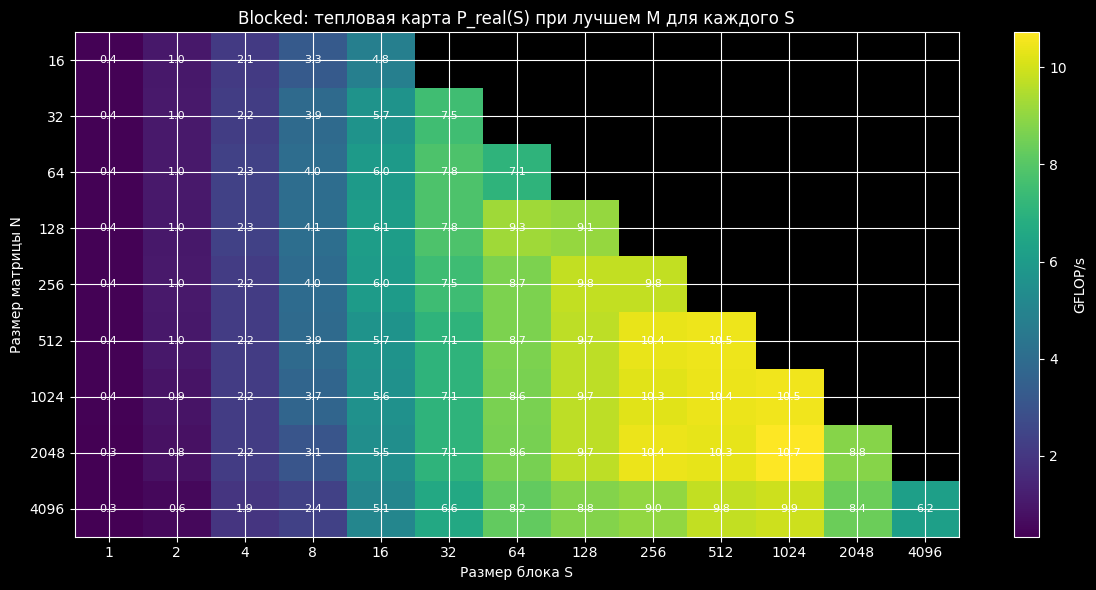

In [48]:
blocked_best_by_S = (
    df_blocked.sort_values(["N", "S", "perf_gflops"], ascending=[True, True, False])
    .groupby(["N", "S"], as_index=False)
    .first()
)

pivot = blocked_best_by_S.pivot(index="N", columns="S", values="perf_gflops")
pivot = pivot.sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(pivot.values, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("Размер блока S")
ax.set_ylabel("Размер матрицы N")
ax.set_title("Blocked: тепловая карта P_real(S) при лучшем M для каждого S")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("GFLOP/s")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

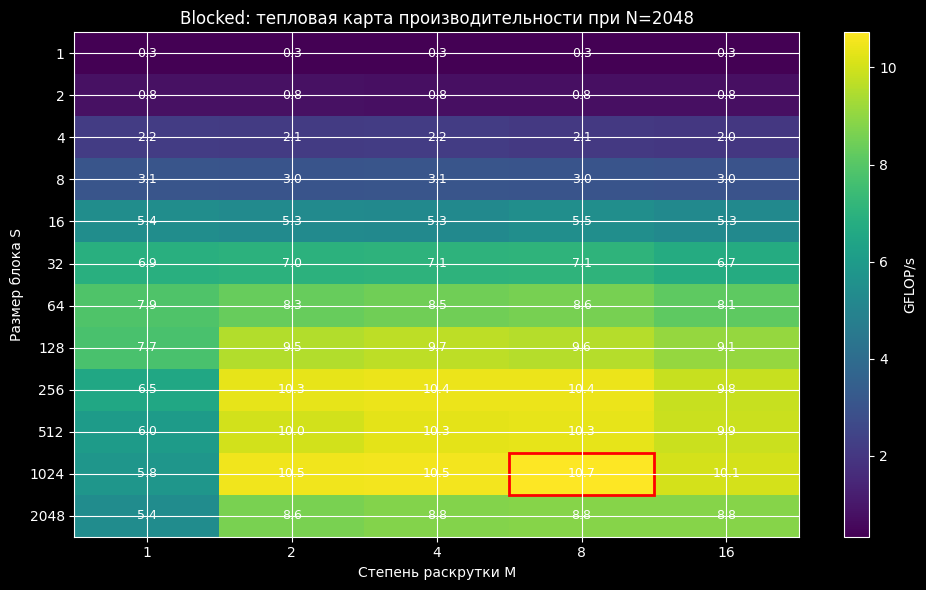

In [53]:
import numpy as np

N_selected = 2048

part = df_blocked[df_blocked["N"] == N_selected].copy()
pivot = part.pivot(index="S", columns="M", values="perf_gflops")
pivot = pivot.sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(pivot.values, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("Степень раскрутки M")
ax.set_ylabel("Размер блока S")
ax.set_title(f"Blocked: тепловая карта производительности при N={N_selected}")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("GFLOP/s")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9)

best_idx = np.unravel_index(np.nanargmax(pivot.values), pivot.values.shape)
i_best, j_best = best_idx

rect = plt.Rectangle((j_best - 0.5, i_best - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2)
ax.add_patch(rect)

plt.tight_layout()
plt.show()

In [50]:
classic_df = df_summary[df_summary["algorithm"] == "Classic"][["N", "time_ms", "perf_gflops"]].rename(
    columns={"time_ms": "classic_time_ms", "perf_gflops": "classic_perf"}
)

tr_prep_df = df_summary[df_summary["algorithm"] == "Transposed (+prep)"][["N", "time_ms", "perf_gflops"]].rename(
    columns={"time_ms": "tr_prep_time_ms", "perf_gflops": "tr_prep_perf"}
)

tr_only_df = df_summary[df_summary["algorithm"] == "Transposed only"][["N", "time_ms", "perf_gflops"]].rename(
    columns={"time_ms": "tr_only_time_ms", "perf_gflops": "tr_only_perf"}
)

compare_transposed = classic_df.merge(tr_prep_df, on="N").merge(tr_only_df, on="N")

compare_transposed["speedup_tr_prep_vs_classic"] = compare_transposed["classic_time_ms"] / compare_transposed["tr_prep_time_ms"]
compare_transposed["speedup_tr_only_vs_classic"] = compare_transposed["classic_time_ms"] / compare_transposed["tr_only_time_ms"]

compare_transposed

,N,classic_time_ms,classic_perf,tr_prep_time_ms,tr_prep_perf,tr_only_time_ms,tr_only_perf,speedup_tr_prep_vs_classic,speedup_tr_only_vs_classic
0,16,0.001,9.102,0.001,9.102,0.001,9.102,1.000000,1.000000
1,32,0.014,4.648,0.014,4.784,0.012,5.461,1.000000,1.166667
2,64,0.142,3.703,0.108,4.837,0.093,5.631,1.314815,1.526882
3,128,1.855,2.261,0.594,7.060,0.447,9.394,3.122896,4.149888
4,256,14.057,2.387,4.909,6.835,4.625,7.255,2.863516,3.039351
5,512,175.078,1.533,44.294,6.060,44.445,6.040,3.952635,3.939206
6,1024,2393.593,0.897,367.403,5.845,359.793,5.969,6.514898,6.652695
7,2048,34178.229,0.503,3074.380,5.588,3064.887,5.605,11.117113,11.151546
8,4096,267054.338,0.515,28535.033,4.816,28354.902,4.847,9.358824,9.418278


In [51]:
best_row = (
    df_blocked[df_blocked["N"] == N_selected]
    .sort_values("perf_gflops", ascending=False)
    .iloc[0]
)

print(f"Для N = {N_selected}:")
print(f"Оптимальный размер блока S* = {int(best_row['S'])}")
print(f"Оптимальная степень раскрутки M* = {int(best_row['M'])}")
print(f"Максимальная производительность P_real = {best_row['perf_gflops']:.3f} GFLOP/s")
print(f"Время выполнения = {best_row['time_ms']:.3f} ms")

Для N = 4096:
Оптимальный размер блока S* = 1024
Оптимальная степень раскрутки M* = 8
Максимальная производительность P_real = 9.932 GFLOP/s
Время выполнения = 13838.368 ms
